In [4]:
# ==========================================================
# CodeAlpha Machine Learning Internship
# Task 1 - Credit Scoring Model
# ==========================================================

# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

plt.style.use("ggplot")

In [5]:
# Load dataset

df = pd.read_csv("german_credit_data.csv")

# Display first five rows
df.head()

,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


In [6]:
# Shape of dataset
print("Dataset Shape:", df.shape)
# Column names
print(df.columns)
# Dataset information
df.info()
# Statistical summary
df.describe()
# Check missing values
df.isnull().sum()

Dataset Shape: (1000, 21)
Index(['laufkont', 'laufzeit', 'moral', 'verw', 'hoehe', 'sparkont', 'beszeit',
       'rate', 'famges', 'buerge', 'wohnzeit', 'verm', 'alter', 'weitkred',
       'wohn', 'bishkred', 'beruf', 'pers', 'telef', 'gastarb', 'kredit'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   laufkont  1000 non-null   int64
 1   laufzeit  1000 non-null   int64
 2   moral     1000 non-null   int64
 3   verw      1000 non-null   int64
 4   hoehe     1000 non-null   int64
 5   sparkont  1000 non-null   int64
 6   beszeit   1000 non-null   int64
 7   rate      1000 non-null   int64
 8   famges    1000 non-null   int64
 9   buerge    1000 non-null   int64
 10  wohnzeit  1000 non-null   int64
 11  verm      1000 non-null   int64
 12  alter     1000 non-null   int64
 13  weitkred  1000 non-null   int64
 14  wohn      1000 non-null   int64


laufkont    0
laufzeit    0
moral       0
verw        0
hoehe       0
sparkont    0
beszeit     0
rate        0
famges      0
buerge      0
wohnzeit    0
verm        0
alter       0
weitkred    0
wohn        0
bishkred    0
beruf       0
pers        0
telef       0
gastarb     0
kredit      0
dtype: int64

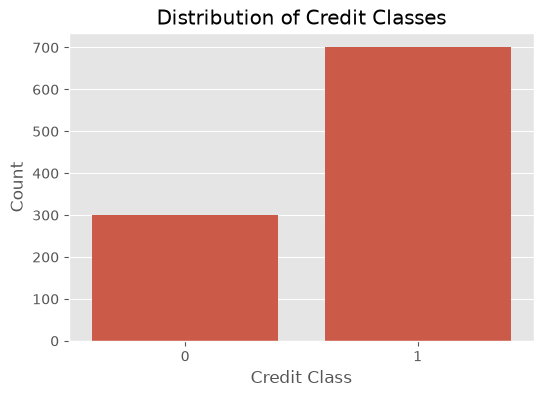

In [7]:
df["kredit"].value_counts()
plt.figure(figsize=(6,4))

sns.countplot(x="kredit", data=df)

plt.title("Distribution of Credit Classes")
plt.xlabel("Credit Class")
plt.ylabel("Count")

plt.show()

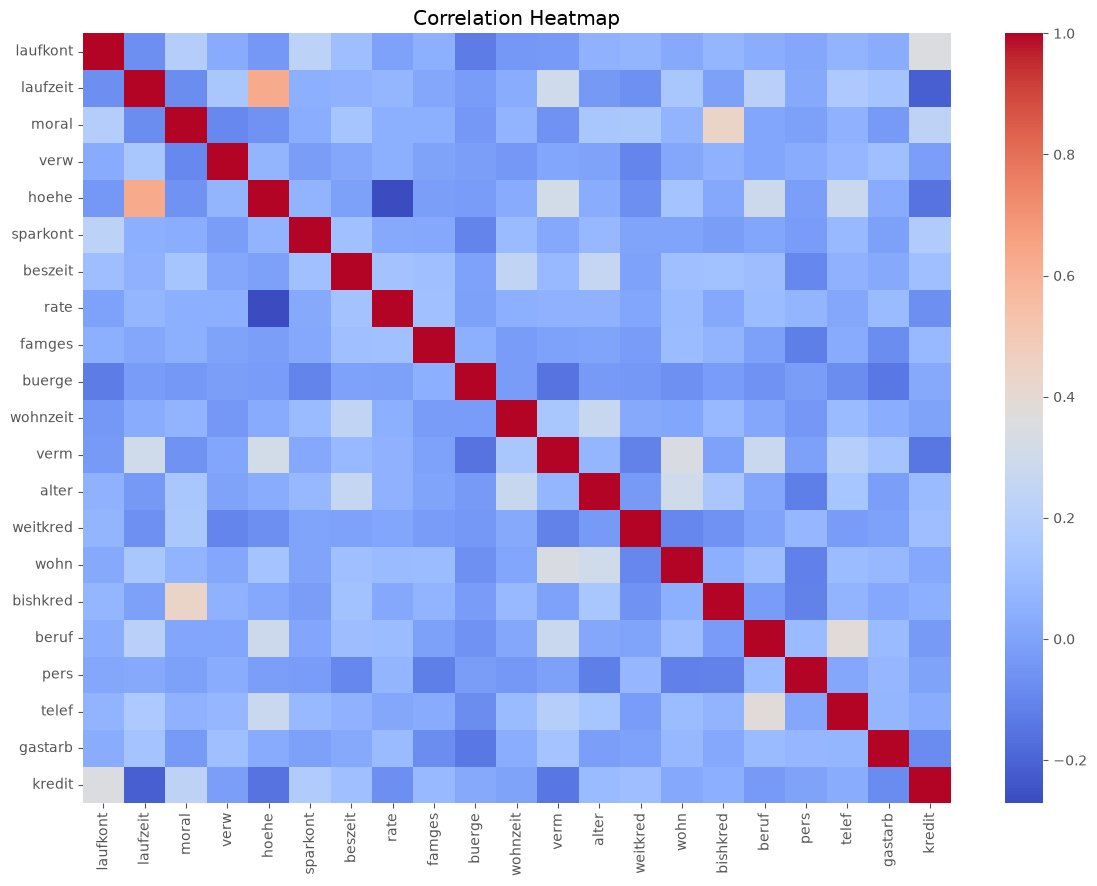

In [8]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(),
            cmap="coolwarm",
            annot=False)

plt.title("Correlation Heatmap")

plt.show()

In [9]:
X = df.drop("kredit", axis=1)

y = df["kredit"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [12]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

Accuracy: 0.77

              precision    recall  f1-score   support

           0       0.66      0.48      0.56        60
           1       0.80      0.89      0.84       140

    accuracy                           0.77       200
   macro avg       0.73      0.69      0.70       200
weighted avg       0.76      0.77      0.76       200



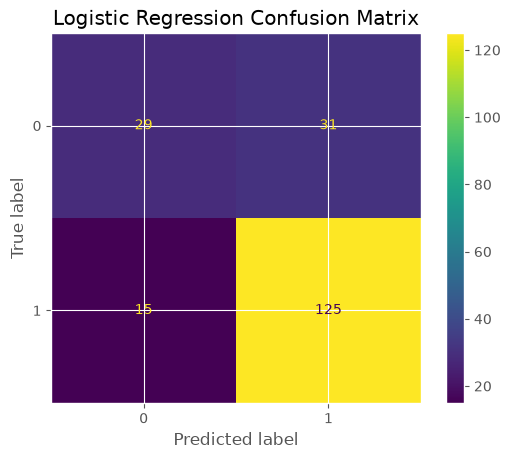

In [13]:
print("Accuracy:", accuracy_score(y_test, lr_pred))
print()

print(classification_report(y_test, lr_pred))

ConfusionMatrixDisplay.from_predictions(y_test, lr_pred)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

Accuracy: 0.695

              precision    recall  f1-score   support

           0       0.49      0.47      0.48        60
           1       0.78      0.79      0.78       140

    accuracy                           0.69       200
   macro avg       0.63      0.63      0.63       200
weighted avg       0.69      0.69      0.69       200



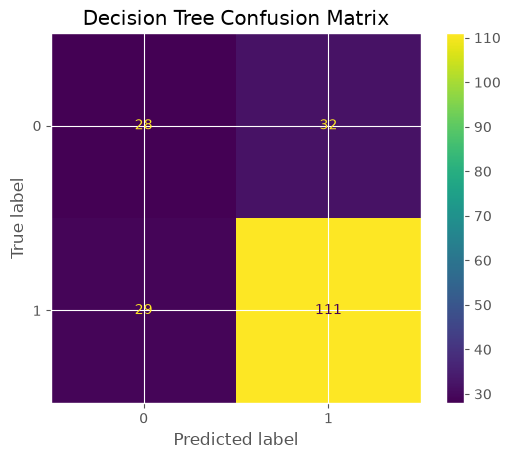

In [14]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))
print()

print(classification_report(y_test, dt_pred))

ConfusionMatrixDisplay.from_predictions(y_test, dt_pred)

plt.title("Decision Tree Confusion Matrix")

plt.show()

Accuracy: 0.795

              precision    recall  f1-score   support

           0       0.73      0.50      0.59        60
           1       0.81      0.92      0.86       140

    accuracy                           0.80       200
   macro avg       0.77      0.71      0.73       200
weighted avg       0.79      0.80      0.78       200



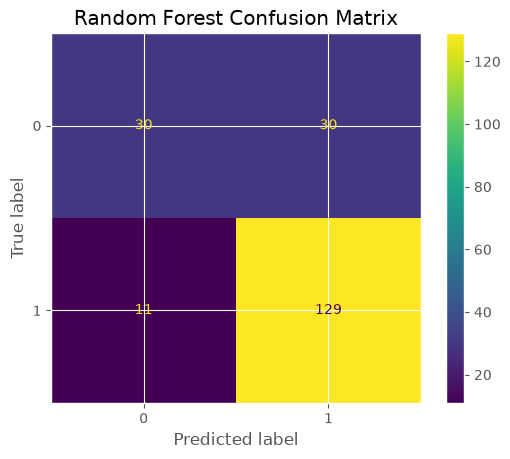

In [15]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print()

print(classification_report(y_test, rf_pred))


ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)

plt.title("Random Forest Confusion Matrix")

plt.show()

In [16]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision":[
        precision_score(y_test, lr_pred, average="weighted"),
        precision_score(y_test, dt_pred, average="weighted"),
        precision_score(y_test, rf_pred, average="weighted")
    ],
    "Recall":[
        recall_score(y_test, lr_pred, average="weighted"),
        recall_score(y_test, dt_pred, average="weighted"),
        recall_score(y_test, rf_pred, average="weighted")
    ],
    "F1 Score":[
        f1_score(y_test, lr_pred, average="weighted"),
        f1_score(y_test, dt_pred, average="weighted"),
        f1_score(y_test, rf_pred, average="weighted")
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.770,0.758625,0.770,0.758524
1,Decision Tree,0.695,0.690725,0.695,0.692706
2,Random Forest,0.795,0.787437,0.795,0.782231


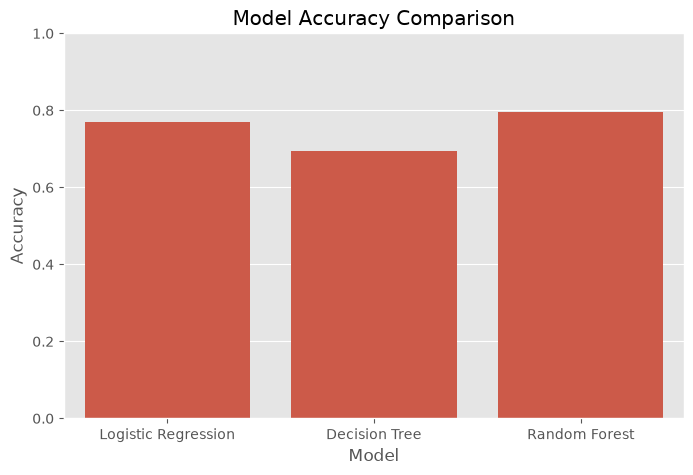

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.title("Model Accuracy Comparison")

plt.ylim(0,1)

plt.show()

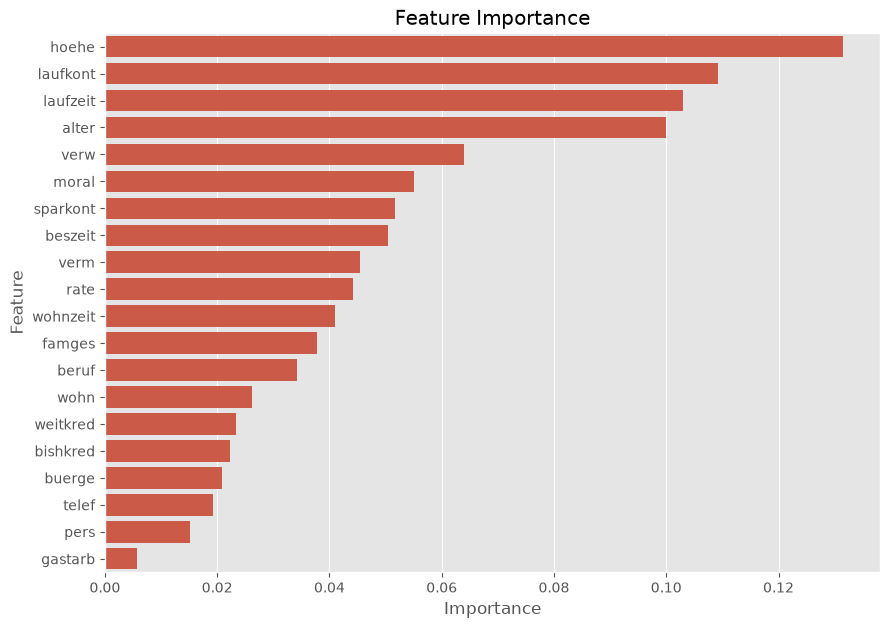

In [18]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

plt.figure(figsize=(10,7))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

c:\Users\Qasim Khan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Qasim Khan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_ranking.py:1364: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


ROC-AUC Score: nan


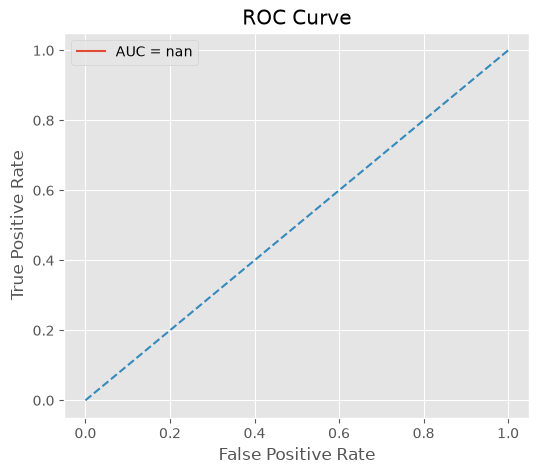

In [19]:
y_prob = rf.predict_proba(X_test)[:,1]

# Convert labels to binary (1=Good, 2=Bad -> 0/1)
y_test_binary = (y_test == 2).astype(int)

auc = roc_auc_score(y_test_binary, y_prob)

print("ROC-AUC Score:", auc)

fpr, tpr, _ = roc_curve(y_test_binary, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## Conclusion

Three classification algorithms were implemented and evaluated for credit scoring.

- Logistic Regression provided a strong baseline with good interpretability.
- Decision Tree captured non-linear relationships but showed signs of overfitting.
- Random Forest achieved the best overall performance due to its ensemble learning approach.

Evaluation metrics including Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC-AUC were used to compare model performance.

Random Forest was selected as the best-performing model for predicting customer creditworthiness.